Neural Networks are specific class of mathematical expressions. This ipynb book demo's how to builds 2 layer Multi layer perceptron.

In [2]:
from graphviz import Digraph
import math

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [3]:
class Value:
    def __init__(self, data, _children=(), _op = '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.grad = 0.0
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data = {self.data})"

    def __add__(self, other):
        # This line is added later
        other = other if isinstance(other, Value) else Value(other)
        
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        # This line is added later
        other = other if isinstance(other, Value) else Value(other)
        
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    # This is something not needed, it is a python trick to be able to do
    # a = Value(3.0)
    # 2 * a --> This can be done because of __rmul__
    def __rmul__(self, other):
        return self * other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        # We have to set this or else it will be 0.
        self.grad = 1.0
        
        for node in reversed(topo):
            node._backward()



---

This example has 3 inputs to a neuron. Each input will have it's weight and bias.

||
|-|
|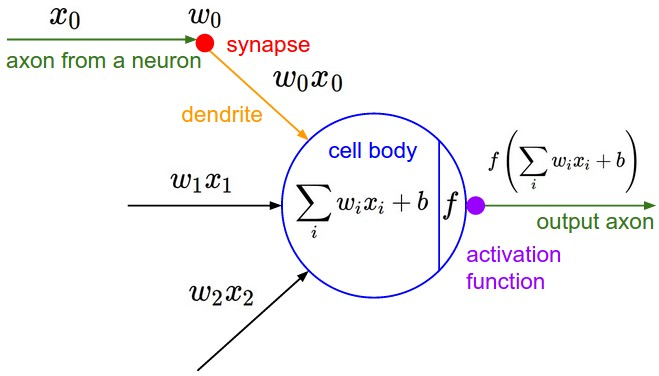|
|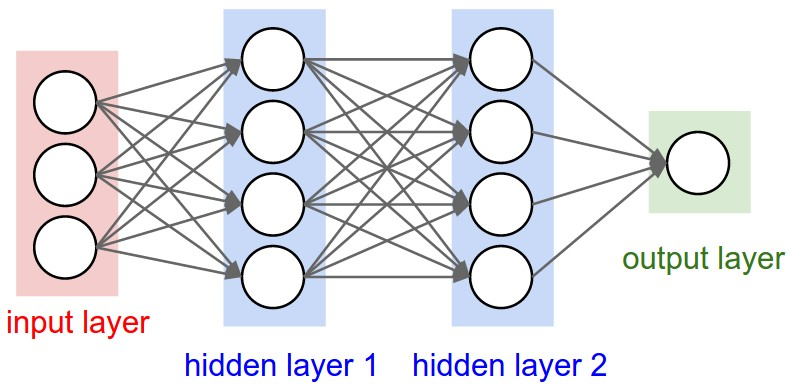|




In [26]:

import random

class Neuron:
    """
    This class represents a single circle in the blue (hidden) or green (output) layers.
    It does not represent the red (input) layer. The red layer is just the raw data.
    
    If the red input layer has 3 circles, it means your data has 3 features (3-dimensional data).
    If you add a new feature to your dataset, you must add another input circle and update the network size.
    
    LLMs (Large Language Models) handle varying sentence lengths differently.
    Instead of changing the network size for every sentence, they use a massive, fixed input size 
    (the context window, like Gemini had a 1M context window). Text is converted to tokens.
    If a sentence is shorter than the context window, 
    the remaining empty inputs are simply filled with zeros (padding).
    
    Is a Neuron a Layer? No.
    A Neuron is just one single circle. A Layer is a vertical column of multiple Neurons standing side-by-side.
    
    Why does the Neuron hold the weights and bias instead of the Layer?
    Each circle needs to look at the data from a slightly different perspective. To do this, 
    each circle must have its own unique set of weights and its own bias. If the Layer held the weights, 
    every circle in that column would be forced to share the exact same weights and calculate the exact 
    same thing, defeating the purpose of having multiple circles!
    """

    def __init__(self, nin):
        """
        nin: Number of inputs to this neuron.
        """
        # We create exactly ONE weight for each input feature. 
        # If the data has 3 features, this single neuron gets 3 weights to evaluate each feature independently.
        # 
        # Why do we need weights and multiply them by x? 
        # If we just used a standalone random number without multiplying by x, the neuron would ignore 
        # the data entirely and output a single static average for every prediction. 
        # Multiplying w * x forces the network to learn the mathematical relationship between the data and the target.
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)] 
        
        # A neuron only ever has ONE bias.
        # Why have a bias? Aren't weights enough?
        # Weights only change how strongly the input affects the output. 
        # But if your input x is 0, weight * 0 is always 0. Your prediction would be stuck at 0.
        # Bias shifts the entire prediction up or down. It gives the neuron a starting baseline, 
        # allowing it to output a value even when the input data is exactly 0.
        self.b = Value(random.uniform(-1, 1)) 

    def __call__(self, x):
        # Crash immediately if the input data doesn't match the number of weights
        assert len(x) == len(self.w), f"Dimension mismatch: Neuron expects {len(self.w)} inputs, got {len(x)}"
        
        # x is your data. It represents the values held in the red input layer.
        # We multiply each weight by its corresponding input, then add the single bias at the end.
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        
        # Why apply an activation function like .tanh()?
        # Without an activation function, the network would just do basic linear math (multiplying and adding). 
        # No matter how many layers you stack, linear math can only draw straight lines. 
        # The activation function introduces non-linearity, allowing the network to bend, curve, 
        # and learn complex patterns in the data (like separating clusters of points).
        out = act.tanh()
        
        return out


"""
# Rough work
# x represents the red input layer. 
# It has 2 items, meaning the data is 2-dimensional (2 circles in the red layer).
x = [2.0, 3.0] 

# We create one neuron for a blue layer. It expects 2 inputs to match the 2 red circles.
# 2 should match number of elements in our x. Or else, zip operator in __call__ will strip away extra weights.
# I have however added another assert to crash earlier with proper exception.
n = Neuron(2)

# We pass the data through the neuron. We reuse this same neuron for every row in the dataset.
n(x)
# """;

In [41]:
class Layer: 
    """
    List of layers
    """
    def __init__(self, nin, nout):
        """
        nin: Number of input neurons?
        nout: How many neurons do we want in this layer?
        """
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs

x = [2.0, 3.0, 4.0]
# Here nin should match number of elements in our input (x) above.
# nout is basically number of neurons in this layer.
n = Layer(nin = 3, nout = 5)
n(x)

[Value(data = 0.8913048724128361),
 Value(data = -0.9990261436116031),
 Value(data = 0.9999933507075938),
 Value(data = -0.1711360254003881),
 Value(data = 0.8247291751235757)]

In [53]:
class MLP:
    """
    Multi Layer Perceptron.
    """
    def __init__(self, nin, nouts):
        """
        nin: we are again taking number of inputs as before
        nouts: instead of taking number of neurons for single layer, we will instead take a list of nouts.
            This list defines sizes of all the layers that we want in our MLP.
        """
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        """
        call them sequentially
        """
        for layer in self.layers:
            x = layer(x)
        return x

# To recreate ![image.png](attachment:5519e1c7-2f9e-4e92-a075-727349486b99.png)
x = [2.0, 3.0, -1.0]
nin = 3 # This should be same as size of x.
# Number of neurons we would want in each layer.
# This can be anything, like [4, 4, 6, 7, 8, 1] or actually anything. 
nouts = [4, 4, 1] 
n = MLP(nin, nouts)
n(x)


[Value(data = 0.002010166958907286)]

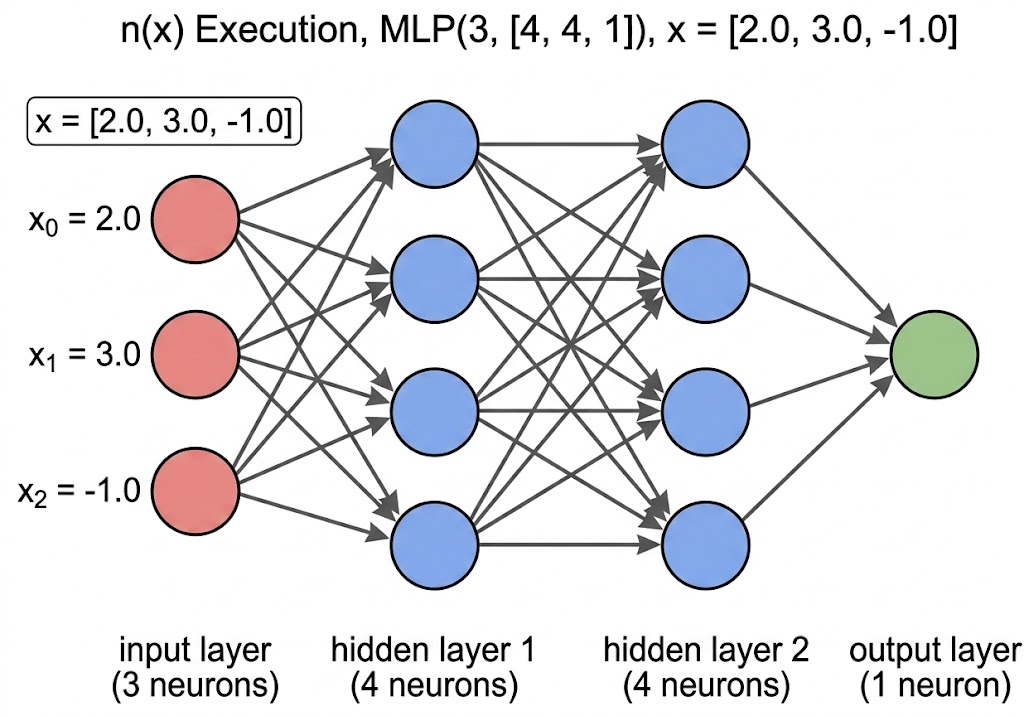

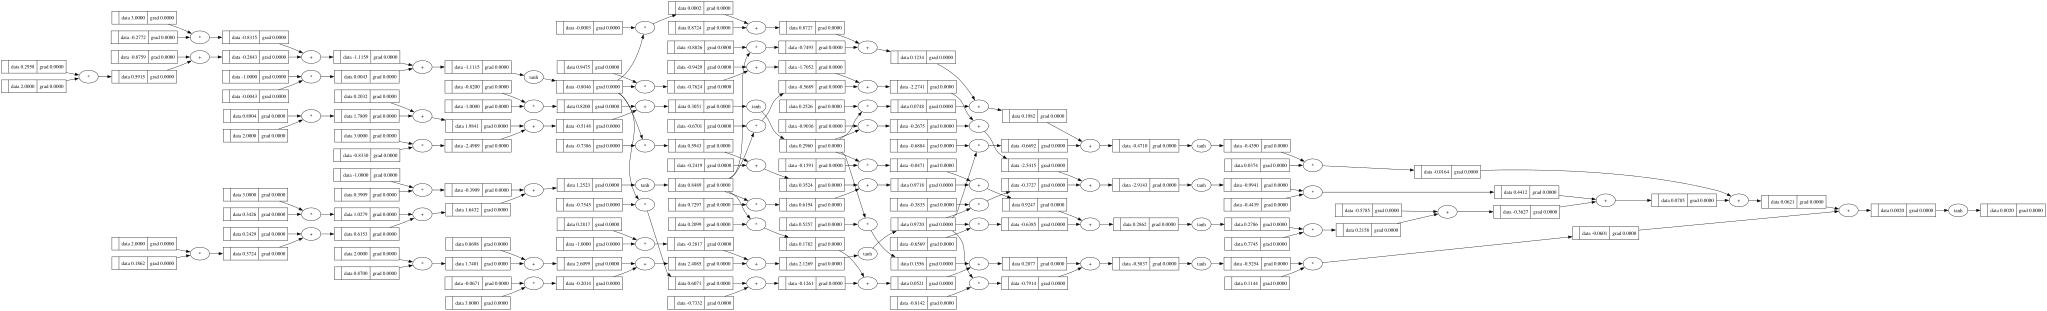

In [56]:
draw_dot(n(x)[0])